Cargamos el dataset, yo utilizo Huggingface

In [1]:
from datasets import load_dataset

ds = load_dataset("uoft-cs/cifar10")

/mnt/c/Users/Usuario UTP/Documents/tareas/redNeuronal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


o numpy

In [2]:
import numpy as np

revisamos las imagenes

alt.LayerChart(...)
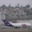
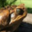
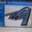
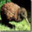
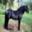
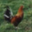
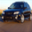
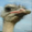
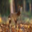
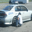
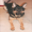
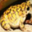
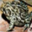
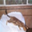
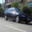

In [56]:
import altair as alt
import pandas as pd
import io
import base64
from PIL import Image

labelToMeaning = {
    0: "airplane",
    1: "automobile",
    2: "bird",
    3: "cat",
    4: "deer",
    5: "dog",
    6: "frog",
    7: "horse",
    8: "ship",
    9: "truck",
}

train_ds = ds["train"]

def image_to_base64(img):
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    buffered = io.BytesIO()
    img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{img_str}"

data_list = []
for i in range(15):
    img_b64 = image_to_base64(train_ds[i]["img"])
    label_num = train_ds[i]["label"]
    data_list.append({
        "image_url": img_b64,
        "label_name": labelToMeaning[label_num],
        "row": i // 5,
        "col": i % 5
    })

df = pd.DataFrame(data_list)
chart = alt.Chart(df).mark_image(
    width=100,
    height=100
).encode(
    x=alt.X('col:O', axis=None),
    y=alt.Y('row:O', axis=None),
    url='image_url',
    tooltip=['label_name']
).properties(
    title="Dataset Preview",
    width=600,
    height=400
)

text = alt.Chart(df).mark_text(dy=60, fontWeight='bold').encode(
    x=alt.X('col:O', axis=None),
    y=alt.Y('row:O', axis=None),
    text='label_name'
)

# Combinar capas y mostrar
(chart + text).configure_view(strokeWidth=0).show()

con numpy

In [11]:
def one_hot_encode(labels, num_classes=10):
    return np.eye(num_classes)[labels]

def as_numpy_array(dataset):
    images = np.array(dataset["img"], dtype=np.float32)
    labels = np.array(dataset["label"], dtype=np.int32)
    images_grayscale = (
        images[:, :, :, 0] * 0.299 +
        images[:, :, :, 1] * 0.587 +
        images[:, :, :, 2] * 0.114
    ) / 255.0
    n_samples, h, w = images_grayscale.shape
    images_flat = images_grayscale.reshape((n_samples, h * w))
    labels_one_hot = one_hot_encode(labels, num_classes=10)
    return images_flat, labels_one_hot

x, y = as_numpy_array(ds["train"])
x_test, y_test = as_numpy_array(ds["test"])

reviso que las shapes de los datos concuerdan e imprimo como se ven las imagenes

alt.LayerChart(...)
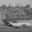
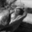
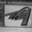
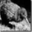
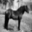
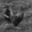
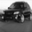
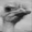
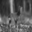
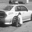
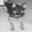
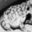
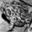
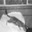
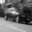

In [5]:
import altair as alt
import pandas as pd
import io
import base64
from PIL import Image
import numpy as np

def image_to_base64(img_array):
    rescaled = (img_array.reshape((32, 32)) * 255).astype(np.uint8)
    img = Image.fromarray(rescaled)

    buffered = io.BytesIO()
    img.save(buffered, format="PNG")
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return f"data:image/png;base64,{img_str}"

data_list = []
for i in range(15):
    img_b64 = image_to_base64(x[i])
    label_num = train_ds[i]["label"]

    data_list.append({
        "image_url": img_b64,
        "label_name": labelToMeaning[label_num],
        "row": i // 5,
        "col": i % 5
    })

df = pd.DataFrame(data_list)

chart = alt.Chart(df).mark_image(
    width=100,
    height=100
).encode(
    x=alt.X('col:O', axis=None),
    y=alt.Y('row:O', axis=None),
    url='image_url',
    tooltip=['label_name']
).properties(
    title="Dataset Preview",
    width=600,
    height=400
)

text = alt.Chart(df).mark_text(dy=60, fontWeight='bold').encode(
    x=alt.X('col:O', axis=None),
    y=alt.Y('row:O', axis=None),
    text='label_name'
)

(chart + text).configure_view(strokeWidth=0).show()

defino mi red neuronal

In [4]:
from typing import List, Callable, Any
def sigmoidea(x: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-x))

def devSigmoidea(x: np.ndarray) -> np.ndarray:
    s = sigmoidea(x)
    return s * (1.0 - s)

def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(x, 0.0)

def devRelu(x: np.ndarray) -> np.ndarray:
    return np.where(x > 0, 1.0, 0.0)

def softmax(x: np.ndarray) -> np.ndarray:
    exp_x = np.exp(x - np.max(x))
    return exp_x / np.sum(exp_x)

def devSoftmax(x: np.ndarray) -> np.ndarray:
    s = softmax(x)
    s_vec = s.reshape(-1)
    jacobian_matrix = np.diag(s_vec) - np.outer(s_vec, s_vec)
    return jacobian_matrix

def mse(predicted: np.ndarray, actually: np.ndarray) -> np.ndarray:
    return np.mean((predicted - actually) ** 2)

def devMse(predicted: np.ndarray, actually: np.ndarray) -> np.ndarray:
    n = predicted.size
    return np.where(n > 0, (2.0 / n) * (predicted - actually), np.zeros_like(predicted))

def lostEntropy(predicted: np.ndarray, actually: np.ndarray) -> np.ndarray:
    eps = 1e-7
    p = np.clip(predicted, eps, 1.0 - eps)
    return -np.sum(actually * np.log(p))

def devLostEntropy(predicted: np.ndarray, actually: np.ndarray) -> np.ndarray:
    eps = 1e-7
    p = np.clip(predicted, eps, 1.0 - eps)
    return -(actually / p)

In [5]:
class Layer:
    def __init__(
            self,
            neurons: int,
            activation: Callable[[np.ndarray], np.ndarray],
            derivada: Callable[[np.ndarray], np.ndarray],
            name: str):
        self.neurons: int = neurons
        self.activacion = activation
        self.derivada = derivada
        self.name: str = name

class Model:
    def __init__(
            self,
            sequential: Any,
            w: List[np.ndarray],
            b: List[np.ndarray]):
        self.sequential = sequential
        self.w = [np.array(weights, dtype=np.float32) for weights in w]
        self.b = [np.array(bias, dtype=np.float32) for bias in b]

    def fordward(self, x: np.ndarray) -> np.ndarray:
      neu = [None] * len(self.sequential)
      z = [None] * len(self.sequential)
      neu[0] = x
      for i in range(1, len(self.sequential)):
        neu[i] = self.sequential[i].activacion(np.dot(neu[i - 1], self.w[i - 1]) + self.b[i])
      return neu[-1]

class Sequential:
    def __init__(self, *layers: Layer):
        self.layers = layers

    def __len__(self):
        return len(self.layers)

    def __getitem__(self, i):
        return self.layers[i]

In [8]:
from typing import Callable
from multiprocessing import Process, Pipe
import psutil
from tqdm import tqdm
import os
import traceback
import time
import math

def __forward(neu, x_sample: np.ndarray, z, sequential, w, b):
    neu[0] = x_sample
    for i in range(1, len(sequential)):
        # print(f"w[{i}] = ", w[i - 1].shape)
        z[i] = np.dot(neu[i - 1], w[i - 1]) + b[i]
        neu[i] = sequential[i].activacion(z[i])

def __evaluateBatch(w, b, x, y, sequential, error, son):
    correct_predictions = 0
    errors = []
    for x_b, y_b in zip(x, y):
        neu_v = [None] * len(sequential)
        z_v = [None] * len(sequential)
        __forward(neu_v, x_b, z_v, sequential, w, b)
        errors.append(error(neu_v[-1], y_b))
        if np.argmax(neu_v[-1]) == np.argmax(y_b):
            correct_predictions += 1
    son.send((correct_predictions, errors))
    son.close()

def __evaluate(w, b, x_test, y_test, sequential, error):
    maxProcess = int(os.getenv("NUM_PROCESS", 1))
    batchForProcess = max(1, x_test.shape[0] // maxProcess)
    correct_predictions = 0
    process = []
    errors = []
    for i in range(maxProcess):
        father, son = Pipe()
        slace_bottom = i * batchForProcess
        if i == maxProcess - 1:
            slace_top = x_test.shape[0] 
        else:
            slace_top = (i+1) * batchForProcess
        x_batch = x_test[slace_bottom : slace_top]
        y_batch = y_test[slace_bottom : slace_top]
        p = Process(target=__evaluateBatch, args=(w, b, x_batch, y_batch, sequential, error, son))
        p.start()
        process.append((p, father))
    for p, conection in process:
        n, e = conection.recv()
        errors.append(e)
        correct_predictions += n
        p.join()
    return (correct_predictions/max(x_test.shape[0], 1), errors)

def __backward(dEdz, z, sequential, w) -> np.ndarray:
    for i in range(len(sequential) - 2, 0, -1):
        # print(f"dEdz[{i+1}]", dEdz[i+1].shape)
        # print(f"dZ[{i}]", sequential[i].derivada(z[i]).shape)
        # print(f"w.t[{i}]", w[i].T.shape)
        # print(f"(dEdz[i+1] @ w[i].T)[{i}]", (dEdz[i+1] @ w[i].T).T.shape)
        dEdz[i] = (dEdz[i+1] @ w[i].T) * sequential[i].derivada(z[i])
        # print(f"dEdz[{i}] = ", dEdz[i])

def __batch(x_b_batch, y_b_batch, w, b, sequential, devError, conn):
    try:
        w_grad_sample_list = [np.zeros_like(wi) for wi in w]
        b_grad_sample_list = [np.zeros_like(bi) for bi in b]
        for x_b, y_b in zip(x_b_batch, y_b_batch):
            neu = [None] * len(sequential)
            z = [None] * len(sequential)
            __forward(neu, x_b, z, sequential, w, b)
            dEdz = [None] * len(sequential)
            de = devError(neu[-1], y_b)
            if de.shape == (1,):
                dEdz[-1] = de * sequential[-1].derivada(z[-1])
            else:
                dEdz[-1] = de @ sequential[-1].derivada(z[-1])
            __backward(dEdz, z, sequential, w)
            for i in range(len(sequential) - 1):
                w_grad_sample_list[i] += np.outer(neu[i], dEdz[i+1])
                b_grad_sample_list[i+1] += dEdz[i+1]
        conn.send(("OK", (w_grad_sample_list, b_grad_sample_list)))
    except Exception as e:
        error_msg = traceback.format_exc()
        conn.send(("ERROR", error_msg))
    finally:
        conn.close()

def __oldBatch(x_b, y_b, w, b, w_grad_batch, b_grad_batch, sequential, devError):
    neu = [None] * len(sequential)
    z = [None] * len(sequential)
    __forward(neu, x_b, z, sequential, w, b)
    dEdz = [None] * len(sequential)
    de = devError(neu[-1], y_b)
    if de.shape == (1,):
      dEdz[-1] = de * sequential[-1].derivada(z[-1])
    else:
      dEdz[-1] = de @ sequential[-1].derivada(z[-1])
    __backward(dEdz, z, sequential, w)
    for i in range(len(sequential) - 1):
        w_grad_sample = np.outer(neu[i], dEdz[i+1])
        w_grad_batch[i] += w_grad_sample
        b_grad_batch[i+1] += dEdz[i+1]

def __fit(
    x: np.ndarray,
    y: np.ndarray,
    epochs: int,
    learningRate: float,
    sequential,
    error: Callable,
    devError: Callable,
    InitB: float,
    batch: int = 1,
    verbose:bool = False,
    test: bool = False,
    x_test: np.ndarray = np.zeros((1)),
    y_test: np.ndarray = np.zeros((1)),
):
    os.environ.pop("OMP_NUM_THREADS", None) 
    os.environ.pop("OPENBLAS_NUM_THREADS", None) 
    os.environ.pop("MKL_NUM_THREADS", None)
    os.environ.pop("VECLIB_MAXIMUM_THREADS", None)
    os.environ.pop("NUMEXPR_NUM_THREADS", None)
    w = []
    b = []
    history = []
    seed = int(os.getenv("seed", 1))
    np.random.seed(seed)
    batch = min(batch, x.shape[0])
    # if test:
    #     bottom = 0
    #     upper = x_test.shape[0]
    #     if upper - batch > 0:
    #         a = np.random.randint(0, upper - batch)
    #         bottom = a * batch
    #         upper = (a + 1) * batch
    #     x_test = x_test[bottom:upper]
    #     y_test = y_test[bottom:upper]
    for i in range(len(sequential)):
        if i < len(sequential) - 1:
            shape = (sequential[i].neurons, sequential[i+1].neurons)
            limit = np.sqrt(6 / (shape[0] + shape[1]))
            w.append(np.random.uniform(-limit, limit, size=shape))
        b.append(np.full((sequential[i].neurons,), InitB))
    for epoch in tqdm(range(epochs), desc="Epocas"):
        for a in range(math.ceil(len(y) / batch)):
            start = time.time_ns()
            x_batch = x[a * batch : (a + 1) * batch]
            y_batch = y[a * batch : (a + 1) * batch]
            w_grad_batch = [np.zeros_like(wi) for wi in w]
            b_grad_batch = [np.zeros_like(bi) for bi in b]
            for x_b, y_b in tqdm(zip(x_batch, y_batch), desc="batch", disable=True):
                __oldBatch(x_b, y_b, w, b, w_grad_batch, b_grad_batch, sequential, devError)
            sumStart = time.time_ns()
            for i in range(len(sequential) - 1):
                w[i] -= learningRate * (w_grad_batch[i] / batch)
                b[i+1] -= learningRate * (b_grad_batch[i+1] / batch)
            end = time.time_ns()
            if verbose:
                (accuracy, batch_losses) = __evaluate(w, b, x[a*batch:(a+1)*batch], y[a*batch:(a+1)*batch], sequential, error)
                test_accuracy = 0
                if test:
                    (test_accuracy, _) = __evaluate(w, b, x_test, y_test, sequential, error)
                cpu_percent = psutil.cpu_percent()
                ram_mb = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
                history.append({
                    "epoch": epoch,
                    "batch": a,
                    "loss_avg": np.mean(batch_losses),
                    "accuracy": accuracy,
                    "test_accuracy": test_accuracy,
                    "cpu_percent":cpu_percent,
                    "ram":ram_mb,
                    "time": (end-start)/1000,
                    "overheadTime":0,
                    "harvestTime": 0,
                    "sumTime": (end - sumStart)/1000
                })
    return (Model(sequential, w, b), history)

def fit(
    x: np.ndarray,
    y: np.ndarray,
    epochs: int,
    learningRate: float,
    sequential,
    error: Callable,
    devError: Callable,
    InitB: float,
    batch: int = 1,
    verbose:bool = False,
    test: bool = False,
    x_test: np.ndarray = np.zeros((1)),
    y_test: np.ndarray = np.zeros((1)),
):
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"
    w = []
    b = []
    history = []
    processList = []
    conections = []
    maxProcess = int(os.getenv("NUM_PROCESS", 1))
    batchForProcess = max(1, batch // maxProcess)
    seed = int(os.getenv("seed", 1))
    np.random.seed(seed)
    # print(batchForProcess)
    batch = min(batch, x.shape[0])
    # if test:
    #     bottom = 0
    #     upper = x_test.shape[0]
    #     if upper - batch > 0:
    #         a = np.random.randint(0, upper - batch)
    #         bottom = a * batch
    #         upper = (a + 1) * batch
    #     x_test = x_test[bottom:upper]
    #     y_test = y_test[bottom:upper]
    for i in range(len(sequential)):
        if i < len(sequential) - 1:
            shape = (sequential[i].neurons, sequential[i+1].neurons)
            limit = np.sqrt(6 / (shape[0] + shape[1]))
            w.append(np.random.uniform(-limit, limit, size=shape))
        b.append(np.full((sequential[i].neurons,), InitB))
    for epoch in tqdm(range(epochs), desc="Epocas"):
        for a in range(math.ceil(len(y) / batch)):
            start = time.time_ns()
            w_grad_batch = [np.zeros_like(wi) for wi in w]
            b_grad_batch = [np.zeros_like(bi) for bi in b]
            startOverhead = time.time_ns()
            for i in range(maxProcess):
                parent, son = Pipe()
                slace_bottom = a * batch + (i) * batchForProcess
                if i == maxProcess - 1:
                    slace_top = a * batch + batch
                else:
                    slace_top = a * batch + (i+1) * batchForProcess
                # print(slace_bottom, slace_top)
                x_batch = x[slace_bottom : slace_top]
                y_batch = y[slace_bottom : slace_top]
                conections.append(parent)
                p = Process(target=__batch, args=(x_batch, y_batch, w, b, sequential, devError, son))
                p.start()
                # print(i)
                processList.append(p)
            endOverhead = time.time_ns()
            harvestTime = 0
            for process, conection in tqdm(zip(processList, conections), desc="Batch", disable=True):
                harvestTimeStart = time.time_ns()
                estado, datos = conection.recv()
                harvestTimeEnd= time.time_ns()
                harvestTime += harvestTimeEnd - harvestTimeStart
                (w_b_single_sample, b_b_single_sample) = datos
                for j in range(len(w_grad_batch)):
                    w_grad_batch[j] += w_b_single_sample[j]
                    b_grad_batch[j+1] += b_b_single_sample[j+1]
                process.join()
            processList = []
            conections = []
            sumStart = time.time_ns()
            for i in range(len(sequential) - 1):
                w[i] -= learningRate * (w_grad_batch[i] / batch)
                b[i+1] -= learningRate * (b_grad_batch[i+1] / batch)
            end = time.time_ns()
            if verbose:
                (accuracy, batch_losses) = __evaluate(w, b, x[a*batch:(a+1)*batch], y[a*batch:(a+1)*batch], sequential, error)
                test_accuracy = 0
                if test:
                    (test_accuracy, _) = __evaluate(w, b, x_test, y_test, sequential, error)
                cpu_percent = psutil.cpu_percent()
                ram_mb = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
                history.append({
                    "epoch": epoch,
                    "batch": a,
                    "loss_avg": np.mean(batch_losses),
                    "accuracy": accuracy,
                    "test_accuracy": test_accuracy,
                    "cpu_percent":cpu_percent,
                    "ram":ram_mb,
                    "time": (end-start)/1000,
                    "overheadTime":(endOverhead-startOverhead)/1000,
                    "harvestTime": harvestTime/1000,
                    "sumTime": (end-sumStart)/1000
                })
    return (Model(sequential, w, b), history)

# ¿Como paralelisamos el algoritmo?
Como se observa anteriormente, nosotros aprobechamos la capacidad que tiene el calculo del bacth para poder dividir el entrenamiento entre el batch.
$$batchPorProceso=\frac{batch}{procesos}$$
Por lo tanto, cada proceso computa batchPorProceso antes de cada actualización de pesos

ahora creemos la red para poder predecir CIFAR10

In [61]:
import pandas as pd
import altair as alt
from sklearn.metrics import confusion_matrix
import io
import base64
from PIL import Image

def plot_loss(history):
    df_history = pd.DataFrame(history)
    df_epoch = df_history.groupby('epoch')['loss_avg'].mean().reset_index()
    line = alt.Chart(df_epoch).mark_line(color='#2196F3', strokeWidth=3).encode(
        x=alt.X('epoch:Q', title='Época', axis=alt.Axis(tickMinStep=1)),
        y=alt.Y('loss_avg:Q', title='Pérdida (loss_avg)', scale=alt.Scale(type='log')), # Escala logarítmica suele ser mejor para loss_avg
        tooltip=['epoch', 'loss_avg']
    )
    points = line.mark_point(size=60, filled=True).encode(
        opacity=alt.value(1)
    )
    return (line + points).properties(
        title='Progreso del Entrenamiento: loss_avg vs Epoch',
        width=600,
        height=300
    ).interactive()

def plot_confusion_matrix(m, x, y, label_names):
    y_pred = np.zeros_like(y)
    for i in range(len(x)):
        y_pred[i] = np.argmax(m.fordward(x[i]))
    cm = confusion_matrix(y, y_pred)
    data = []
    for i in range(len(cm)):
        for j in range(len(cm)):
            data.append({
                'Actual': str(label_names[i]),
                'Predicho': str(label_names[j]),
                'Cantidad': int(cm[i, j])
            })
    df_cm = pd.DataFrame(data)
    threshold = float(cm.max() / 2)
    base = alt.Chart(df_cm).encode(
        x=alt.X('Predicho:O', title='Clase Predicha', sort=list(label_names.values())),
        y=alt.Y('Actual:O', title='Clase Real', sort=list(label_names.values()))
    )
    heatmap = base.mark_rect().encode(
        color=alt.Color('Cantidad:Q', scale=alt.Scale(scheme='blues'), title='Frecuencia'),
        tooltip=['Actual', 'Predicho', 'Cantidad']
    )
    text = base.mark_text(baseline='middle').encode(
        text='Cantidad:Q',
        color=alt.condition(
            f"datum.Cantidad > {threshold}",
            alt.value('white'),
            alt.value('black')
        )
    )
    return (heatmap + text).properties(
        title='Matriz de Confusión (CIFAR-10)',
        width=500,
        height=500,
    ).configure_axis(
        labelFontSize=12,
        titleFontSize=14
    )

def plot_accuracy_only(history):
    df_history = pd.DataFrame(history)
    df_epoch = df_history.groupby('epoch')['accuracy'].mean().reset_index()
    line = alt.Chart(df_epoch).mark_line(color='#2196F3', strokeWidth=3).encode(
        x=alt.X('epoch:Q', title='Época', axis=alt.Axis(tickMinStep=1)),
        y=alt.Y('accuracy:Q', title='Pérdida (accuracy)', scale=alt.Scale(type='log')), # Escala logarítmica suele ser mejor para accuracy
        tooltip=['epoch', 'accuracy']
    )
    points = line.mark_point(size=60, filled=True).encode(
        opacity=alt.value(1)
    )
    return (line + points).properties(
        title='Progreso del Entrenamiento: accuracy vs Epoch',
        width=600,
        height=300
    ).interactive()

def plot_time(history):
    df_history = pd.DataFrame(history)
    df_history = df_history.rename(columns={'time': 'totalTime'})
    
    df_epoch = df_history.groupby('epoch').agg({
        'totalTime': 'mean',
        'overheadTime': 'mean',
        'harvestTime': 'mean',
        'sumTime': 'mean'
    }).reset_index()
    df_melted = df_epoch.melt(
        id_vars=['epoch'], 
        value_vars=['totalTime', 'overheadTime', 'harvestTime', 'sumTime'],
        var_name='Metrica', 
        value_name='ms'
    )
    nearest = alt.selection_point(nearest=True, on='mouseover', 
                                  fields=['epoch'], empty=False)
    lines = alt.Chart(df_melted).mark_line(strokeWidth=3).encode(
        x=alt.X('epoch:Q', title='Época'),
        y=alt.Y('ms:Q', title='Tiempo (ms)', scale=alt.Scale(type='symlog')), 
        color=alt.Color('Metrica:N', scale=alt.Scale(
            domain=['totalTime', 'overheadTime', 'harvestTime', 'sumTime'],
            range=['#2196F3', '#FF5722', '#000000', '#00913F']
        ))
    )
    selectors = alt.Chart(df_epoch).mark_rule(color='gray', strokeWidth=1).encode(
        x='epoch:Q',
        opacity=alt.condition(nearest, alt.value(0.3), alt.value(0)),
        tooltip=[
            alt.Tooltip('epoch:Q', title='Época'),
            alt.Tooltip('totalTime:Q', title='Tiempo Total (ms)', format='.2f'),
            alt.Tooltip('overheadTime:Q', title='Overhead (ms)', format='.2f'),
            alt.Tooltip('harvestTime:Q', title='Harvest (ms)', format='.2f'),
            alt.Tooltip('sumTime:Q', title='Sum (ms)', format='.2f'),
        ]
    ).add_params(nearest)
    points = lines.mark_point(size=80, filled=True).encode(
        opacity=alt.condition(nearest, alt.value(1), alt.value(0))
    )
    return (lines + selectors + points).properties(
        title='Análisis de Rendimiento',
        width=600,
        height=300,
    ).interactive()

def plot_wall_of_shame(m, x_test, y_test, label_names, num_errors=15):
    errors_found = []
    for i in range(len(x_test)):
        if len(errors_found) >= num_errors:
            break
        output = m.fordward(x_test[i])
        pred_idx = np.argmax(output)
        actual_idx = y_test[i]
        if pred_idx != actual_idx:
            img_array = (x_test[i].reshape((32, 32)) * 255).astype(np.uint8)
            img_pil = Image.fromarray(img_array)
            buffered = io.BytesIO()
            img_pil.save(buffered, format="PNG")
            img_b64 = base64.b64encode(buffered.getvalue()).decode("utf-8")
            actual_name = label_names[actual_idx]
            pred_name = label_names[pred_idx]
            errors_found.append({
                "image": f"data:image/png;base64,{img_b64}",
                "Actual": actual_name,
                "Predicho": pred_name,
                "Leyenda": f"Real: {actual_name} | Pred: {pred_name}",
                "Confianza": float(np.max(output)),
                "row": len(errors_found) // 5,
                "col": len(errors_found) % 5
            })
    df_errors = pd.DataFrame(errors_found)
    base = alt.Chart(df_errors).encode(
        x=alt.X('col:O', axis=alt.Axis(labels=False, ticks=False, title=None)),
        y=alt.Y('row:O', axis=alt.Axis(labels=False, ticks=False, title=None))
    )
    image_layer = base.mark_image(width=70, height=70).encode(
        url='image',
        tooltip=['Actual', 'Predicho', 'Confianza']
    ).properties(
        title="Dataset Preview",
        width=600,
        height=400,
    )
    text_layer = base.mark_text(
        dy=55,
        fontSize=10,
        fontWeight='bold'
    ).encode(
        text='Leyenda:N',
        color=alt.value('#D32F2F')
    )
    return (image_layer + text_layer).properties(
        title="Wall of Shame: Errores del Modelo",
        padding=30
    ).configure_view(strokeWidth=0)
    
def plot_accuracy(history):
    df_history = pd.DataFrame(history)
    df_epoch = df_history.groupby('epoch').agg({
        'accuracy': 'mean',
        'test_accuracy': 'mean'
    }).reset_index()
    df_melted = df_epoch.melt(
        id_vars=['epoch'], 
        value_vars=['accuracy', 'test_accuracy'],
        var_name='Dataset', 
        value_name='Acc'
    )
    base = alt.Chart(df_melted).encode(
        x=alt.X('epoch:Q', title='Época', axis=alt.Axis(tickMinStep=1)),
        y=alt.Y('Acc:Q', title='Exactitud (Accuracy)', scale=alt.Scale(domain=[0, 1])),
        color=alt.Color('Dataset:N', scale=alt.Scale(
            domain=['accuracy', 'test_accuracy'],
            range=['#2196F3', '#FF9800']
        ), title='Leyenda')
    )
    lines = base.mark_line(strokeWidth=3)
    points = base.mark_point(size=60, filled=True)
    # selección más cercana para mostrar tooltips con ambos valores (train/test)
    nearest = alt.selection_point(nearest=True, on='mouseover', fields=['epoch'], empty='none')
    tooltip_rule = alt.Chart(df_epoch).mark_rule(color='gray').encode(
        x='epoch:Q',
        opacity=alt.condition(nearest, alt.value(0.3), alt.value(0)),
        tooltip=[
            alt.Tooltip('epoch:Q', title='Época'),
            alt.Tooltip('accuracy:Q', title='Train Acc', format='.2%'),
            alt.Tooltip('test_accuracy:Q', title='Test Acc', format='.2%')
        ]
    ).add_selection(nearest)
    return (lines + points + tooltip_rule).properties(
        title='Evolución del Accuracy: Entrenamiento vs. Prueba',
        width=600,
        height=300,
    ).interactive()


revisemos el ambiente en que nos encontramos

In [10]:
import platform
import psutil
print("sistema operativo: ", platform.platform())
print("tipo sistema operativo: ", platform.system())
print("Núcleos físicos:", psutil.cpu_count(logical=False))
print("Núcleos totales (lógicos):", psutil.cpu_count(logical=True))
print("Procesador:", platform.processor())
print("Arquitectura:", platform.machine())
freq = psutil.cpu_freq()
print(f"Frecuencia máxima: {freq.max:.2f} Mhz")
print(f"Frecuencia actual: {freq.current:.2f} Mhz")

sistema operativo:  Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with
tipo sistema operativo:  Linux
Núcleos físicos: 10
Núcleos totales (lógicos): 20
Procesador: 
Arquitectura: x86_64
Frecuencia máxima: 0.00 Mhz
Frecuencia actual: 2112.00 Mhz


bueno, comencemos con las pruebas

Comencemos observando que tan buena es la red.

In [17]:
os.environ["NUM_PROCESS"] = "1"
(modelSerial, historyComplete) = __fit(
    x=x,
    y=y,
    epochs=30,
    learningRate=0.1,
    sequential=Sequential(
        Layer(1024, relu, devRelu, "input"),
        Layer(512, relu, devRelu, "hidden"),
        Layer(128, relu, devRelu, "hidden"),
        Layer(10, softmax, devSoftmax, "output")
    ),
    error=lostEntropy,
    devError=devLostEntropy,
    InitB=0.15,
    batch=16384,
    verbose=True,
    test=True,
    x_test=x_test,
    y_test=y_test
)

Epocas: 100%|██████████| 30/30 [1:37:41<00:00, 195.37s/it]


ahora, que tan buena es la red prediciendo

In [20]:
plot_confusion_matrix(modelSerial, x_test, ds["test"]["label"], labelToMeaning).show()

alt.LayerChart(...)

revicemos como le fue a la red en acurracy

In [62]:
plot_time(historyComplete).show()

alt.LayerChart(...)

In [26]:
plot_accuracy(historyComplete).show()
plot_loss(historyComplete).show()

/tmp/ipykernel_19875/1597030628.py:213: AltairDeprecationWarning: 
Deprecated since `altair=5.0.0`. Use add_params instead.
  ).add_selection(nearest)


alt.LayerChart(...)

alt.LayerChart(...)

listo, ahora, revicemos que tan rapida es nuestra solución con diferentes tamaños de paralelización

In [ ]:
times = []
maxI = 5
# utilizamos primero de prueba una versión sin multiprocess, osea, sin el overhead del paralelismo
for _ in range(maxI):
    start = time.time_ns()
    __fit(
        x=x,
        y=y,
        epochs=1,
        learningRate=0.1,
        sequential=Sequential(
            Layer(1024, relu, devRelu, "input"),
            Layer(512, relu, devRelu, "hidden"),
            Layer(128, relu, devRelu, "hidden"),
            Layer(10, softmax, devSoftmax, "output")
        ),
        error=lostEntropy,
        devError=devLostEntropy,
        InitB=0.15,
        batch=16384,
        verbose=False,
        test=False,
        x_test=x_test,
        y_test=y_test
    )
    end = time.time_ns()
    times.append({
        "processNumber":1,
        "time":(end-start)/1000,
        "overhead":False
    })
for processNumber in [1, 2, 4, 8, 16]:
    os.environ["NUM_PROCESS"] = str(processNumber)
    for _ in range(maxI):
        start = time.time_ns()
        fit(
            x=x,
            y=y,
            epochs=1,
            learningRate=0.1,
            sequential=Sequential(
                Layer(1024, relu, devRelu, "input"),
                Layer(512, relu, devRelu, "hidden"),
                Layer(128, relu, devRelu, "hidden"),
                Layer(10, softmax, devSoftmax, "output")
            ),
            error=lostEntropy,
            devError=devLostEntropy,
            InitB=0.15,
            batch=16384,
            verbose=False,
            test=False,
            x_test=x_test,
            y_test=y_test
        )
        end = time.time_ns()
        times.append({
            "processNumber":processNumber,
            "time":(end-start)/1000,
            "overhead":True
        })

Epocas: 100%|██████████| 1/1 [05:46<00:00, 346.36s/it]


Ya teniendo lso datos de la velocidad de ejecución, comparemos las velocidades

In [ ]:
import pandas as pd
import altair as alt

def plot_speedup(times):
    df = pd.DataFrame(times)
    df = df.dropna() 
    base_time = df[df['overhead'] == False]['time'].mean()
    df_stats = df.groupby(['processNumber', 'overhead'])['time'].mean().reset_index()
    df_stats['speedup'] = base_time / df_stats['time']
    max_p = int(df_stats['processNumber'].max())
    ideal_df = pd.DataFrame({
        'processNumber': [1, max_p],
        'speedup': [1, max_p],
        'Tipo': ['Ideal', 'Ideal']
    })
    chart_time = alt.Chart(df_stats).mark_line(point=True).encode(
        x=alt.X('processNumber:Q', title='Número de Procesos'),
        y=alt.Y('time:Q', title='Tiempo (ms)'),
        color=alt.value('#f44336'),
        tooltip=['processNumber', 'time']
    ).properties(title='Tiempo de Ejecución', width=250, height=250)
    line_real = alt.Chart(df_stats).mark_line(color='#2196F3', point=True).encode(
        x=alt.X('processNumber:Q'),
        y=alt.Y('speedup:Q', title='Speedup (x veces más rápido)'),
        tooltip=['processNumber', 'speedup']
    )
    line_ideal = alt.Chart(ideal_df).mark_line(color='gray', strokeDash=[5,5]).encode(
        x='processNumber:Q',
        y='speedup:Q'
    )
    chart_speedup = (line_real + line_ideal).properties(
        title='Speedup Real vs Ideal',
        width=250,
        height=250
    )

    return (chart_time | chart_speedup)

plot_speedup(times)

alt.HConcatChart(...)

# ¿Que deberiamos observar?
Segun la ley de <b>Ley de Amdahl</b>, la mejora de un algoritmo paralelo esta limitada a la fracción de tiempo que  no se paraleliza. $$\frac{T_{serial}}{T_{paralelo}}$$
## ¿Que puede estar pasando para que no se cumpla?
Se puede observar que el tiempo no disminuye con mas nuemero de procesos nosotros asignemos. 

| proceso | bact por proceso |
|---------|------------------|
| 1       | 16384            |
| 2       | 8192             |
| 4       | 4096             |
| 8       | 2048             |
| 16      | 1024             |

Si observamos la tabla, aunque cada nucleo en general se encarga de $$\frac{50000}{procesos}$$ del dataset total, pero, en cada batch en vez de computar mas del batch, computa menos por nucleo, por lo tanto, el overhead de copiar los datos y crear el proceso supera la ganacia de computar en paralelo cada batch.

intentemos observar que pasa con el tiempo con un batch mas alto con 8 nucleos y cambiamos de batch

In [22]:
os.environ["NUM_PROCESS"] = "8"
batchTimes = []
for i in range(6):
    batchSize = 2**(10+i)
    print(batchSize)
    start = time.time_ns()
    fit(
        x=x,
        y=y,
        epochs=1,
        learningRate=0.1,
        sequential=Sequential(
            Layer(1024, relu, devRelu, "input"),
            Layer(512, relu, devRelu, "hidden"),
            Layer(128, relu, devRelu, "hidden"),
            Layer(10, softmax, devSoftmax, "output")
        ),
        error=lostEntropy,
        devError=devLostEntropy,
        InitB=0.15,
        batch=batchSize,
        verbose=False,
        test=False
    )
    end = time.time_ns()
    batchTimes.append({
        "processNumber":processNumber,
        "time":(end-start)/1000,
        "overhead":True,
        "batch_size": batchSize
    })

1024


Epocas: 100%|██████████| 1/1 [05:59<00:00, 359.89s/it]


2048


Epocas: 100%|██████████| 1/1 [05:59<00:00, 359.68s/it]


4096


...

Epocas: 100%|██████████| 1/1 [05:52<00:00, 352.34s/it]


16384


Epocas: 100%|██████████| 1/1 [06:07<00:00, 367.98s/it]


32768


Epocas: 100%|██████████| 1/1 [03:41<00:00, 221.48s/it]


Revicemos los datos...

In [23]:
def plot_batch_performance(data):
    df = pd.DataFrame(data)
    chart = alt.Chart(df).mark_line(point=True, color='#4CAF50').encode(
        x=alt.X('batch_size:Q', 
                title='Tamaño del Batch (Escala Log2)', 
                scale=alt.Scale(type='log', base=2)),
        y=alt.Y('time:Q', 
                title='Tiempo de Ejecución (ms)',
                scale=alt.Scale(zero=False)),
        tooltip=['batch_size', 'time']
    ).properties(
        title='Impacto del Batch Size en el Rendimiento (8 Procesos)',
        width=600,
        height=350
    ).interactive()
    
    return chart

plot_batch_performance(batchTimes)

alt.Chart(...)

Bueno y si intentamos algo para eliminar algo de tiempo de overhead.

In [66]:
from typing import Callable, Tuple
from multiprocessing import Process, Pipe, shared_memory
import psutil
from tqdm import tqdm
import os
import traceback
import time
import math

def __batch_shr(bottom, top, w, b, x_shape: Tuple[int, int], y_shape: Tuple[int, int], sequential, devError, conn):
    try:
        # w = []
        # b = []
        w_grad_sample_list = []
        b_grad_sample_list = []
        shm_x = shared_memory.SharedMemory(name=f"x")
        x = np.ndarray(
            x_shape, 
            dtype=np.float32, 
            buffer=shm_x.buf
        )
        shm_y = shared_memory.SharedMemory(name=f"y")
        y = np.ndarray(
            y_shape, 
            dtype=np.float32, 
            buffer=shm_y.buf
        )
        start = time.time_ns()
        for i in range(len(sequential)):
            if i < len(sequential) - 1:
                # shm = shared_memory.SharedMemory(name=f"w{i}")
                # arr = np.ndarray(
                #     (sequential[i].neurons, sequential[i+1].neurons), 
                #     dtype=np.float32, 
                #     buffer=shm.buf
                # )
                # w.append(arr)
                w_grad_sample_list.append(np.zeros_like(w[i]))
            # shm = shared_memory.SharedMemory(name=f"w{i}")
            # arr = np.ndarray(
            #     (sequential[i].neurons, ), 
            #     dtype=np.float32, 
            #     buffer=shm.buf
            # )
            # b.append(arr)
            b_grad_sample_list.append(np.zeros_like(b[i]))
        # print("tiempo arbes", (time.time_ns()-start)/10**9, " ", bottom, top)
        start = time.time_ns()
        for x_b, y_b in zip(x[bottom:top], y[bottom:top]):
            neu = [None] * len(sequential)
            z = [None] * len(sequential)
            __forward(neu, x_b, z, sequential, w, b)
            dEdz = [None] * len(sequential)
            de = devError(neu[-1], y_b)
            if de.shape == (1,):
                dEdz[-1] = de * sequential[-1].derivada(z[-1])
            else:
                dEdz[-1] = de @ sequential[-1].derivada(z[-1])
            __backward(dEdz, z, sequential, w)
            for i in range(len(sequential) - 1):
                w_grad_sample_list[i] += np.outer(neu[i], dEdz[i+1])
                b_grad_sample_list[i+1] += dEdz[i+1]
        # print("suma del hilo: ", (time.time_ns()-start)/10**9, " ",bottom, top)
        conn.send(("OK", (w_grad_sample_list, b_grad_sample_list)))
    except Exception as e:
        error_msg = traceback.format_exc()
        print("error en proceso")
        print(error_msg)
        conn.send(("ERROR", error_msg))
    finally:
        conn.close()
        
def __initSharedMemory(x: np.ndarray, name: str):
    shm = shared_memory.SharedMemory(create=True, size=x.nbytes, name=name)
    view = np.ndarray(x.shape, dtype=x.dtype, buffer=shm.buf)
    view[:] = x[:]
    return shm, view

def fit_shr(
    x: np.ndarray,
    y: np.ndarray,
    epochs: int,
    learningRate: float,
    sequential,
    error: Callable,
    devError: Callable,
    InitB: float,
    batch: int = 1,
    verbose:bool = False,
    test: bool = False,
    x_test: np.ndarray = np.zeros((1)),
    y_test: np.ndarray = np.zeros((1)),
):
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"
    w = []
    b = []
    history = []
    try:
        conections = []
        maxProcess = int(os.getenv("NUM_PROCESS", 1))
        batchForProcess = max(1, batch // maxProcess)
        seed = int(os.getenv("seed", 1))
        np.random.seed(seed)
        batch = min(batch, x.shape[0])
        x_share, _ = __initSharedMemory(x, "x")
        y_share, _ = __initSharedMemory(y, "y")
        # for i in range(len(sequential)):
        #     if i < len(sequential) - 1:
        #         shape = (sequential[i].neurons, sequential[i+1].neurons)
        #         limit = np.sqrt(6 / (shape[0] + shape[1]))
        #         wi, _ = __initSharedMemory(np.random.uniform(-limit, limit, size=shape), f"w{i}")
        #         w.append(wi)
        #     bi, _ = __initSharedMemory(np.full((sequential[i].neurons,), InitB), f"b{i}")
        #     b.append(bi)
        for i in range(len(sequential)):
            if i < len(sequential) - 1:
                shape = (sequential[i].neurons, sequential[i+1].neurons)
                limit = np.sqrt(6 / (shape[0] + shape[1]))
                w.append(np.random.uniform(-limit, limit, size=shape))
            b.append(np.full((sequential[i].neurons,), InitB))
        for epoch in tqdm(range(epochs), desc="Epocas"):
            for a in range(math.ceil(len(y) / batch)):
                start = time.time_ns()
                w_grad_batch = [np.zeros_like(wi) for wi in w]
                b_grad_batch = [np.zeros_like(bi) for bi in b]
                startOverhead = time.time_ns()
                for i in range(maxProcess):
                    parent, son = Pipe()
                    slace_bottom = a * batch + (i) * batchForProcess
                    if i == maxProcess - 1:
                        slace_top = a * batch + batch
                    else:
                        slace_top = a * batch + (i+1) * batchForProcess
                    t = time.time_ns()
                    p = Process(
                        target=__batch_shr, 
                        args=(
                            slace_bottom, 
                            slace_top, 
                            w,
                            b,
                            x.shape, 
                            y.shape, 
                            sequential,
                            devError, 
                            son
                            )
                        )
                    p.start()
                    # print(f"hilo {i}: ", (time.time_ns()-t)/10**9)
                    conections.append((p, parent))
                endOverhead = time.time_ns()
                harvestTime = 0
                for process, conection in tqdm(conections, desc="Batch", disable=True):
                    harvestTimeStart = time.time_ns()
                    estado, datos = conection.recv()
                    harvestTimeEnd= time.time_ns()
                    harvestTime += harvestTimeEnd - harvestTimeStart
                    (w_b_single_sample, b_b_single_sample) = datos
                    for j in range(len(w_grad_batch)):
                        w_grad_batch[j] += w_b_single_sample[j]
                        b_grad_batch[j+1] += b_b_single_sample[j+1]
                    process.join()
                conections = []
                sumStart = time.time_ns()
                for i in range(len(sequential) - 1):
                    w[i] -= learningRate * (w_grad_batch[i] / batch)
                    b[i+1] -= learningRate * (b_grad_batch[i+1] / batch)
                end = time.time_ns()
                if verbose:
                    (accuracy, batch_losses) = __evaluate(w, b, x[a*batch:(a+1)*batch], y[a*batch:(a+1)*batch], sequential, error)
                    test_accuracy = 0
                    if test:
                        (test_accuracy, _) = __evaluate(w, b, x_test, y_test, sequential, error)
                    cpu_percent = psutil.cpu_percent()
                    ram_mb = psutil.Process(os.getpid()).memory_info().rss / (1024 * 1024)
                    history.append({
                        "epoch": epoch,
                        "batch": a,
                        "loss_avg": np.mean(batch_losses),
                        "accuracy": accuracy,
                        "test_accuracy": test_accuracy,
                        "cpu_percent":cpu_percent,
                        "ram":ram_mb,
                        "time": (end-start)/1000,
                        "overheadTime":(endOverhead-startOverhead)/1000,
                        "harvestTime": harvestTime/1000,
                        "sumTime": (end-sumStart)/1000
                    })
    finally:
        shm = shared_memory.SharedMemory(name="x")
        shm.close()
        shm.unlink()
        shm = shared_memory.SharedMemory(name="y")
        shm.close()
        shm.unlink()
    return (Model(sequential, w, b), history)

bueno, comencemos a comparar tiempos entre diferentes soluciones.

In [ ]:
os.environ["NUM_PROCESS"] = "8"
(modeloSerial, historiaSerial) = __fit(
    x=x,
    y=y,
    epochs=5,
    learningRate=0.1,
    sequential=Sequential(
        Layer(1024, relu, devRelu, "input"),
        Layer(512, relu, devRelu, "hidden"),
        Layer(128, relu, devRelu, "hidden"),
        Layer(10, softmax, devSoftmax, "output")
    ),
    error=lostEntropy,
    devError=devLostEntropy,
    InitB=0.15,
    batch=8192,
    verbose=True,
    test=False,
    x_test=x_test,
    y_test=y_test
)
(modeloParalelo, historiaParalelo) = fit(
    x=x,
    y=y,
    epochs=5,
    learningRate=0.1,
    sequential=Sequential(
        Layer(1024, relu, devRelu, "input"),
        Layer(512, relu, devRelu, "hidden"),
        Layer(128, relu, devRelu, "hidden"),
        Layer(10, softmax, devSoftmax, "output")
    ),
    error=lostEntropy,
    devError=devLostEntropy,
    InitB=0.15,
    batch=8192,
    verbose=True,
    test=False,
    x_test=x_test,
    y_test=y_test
)

Epocas: 100%|██████████| 5/5 [43:40<00:00, 524.18s/it]


NameError: name 'fit_shr' is not defined

In [64]:
plot_time(historiaSerial).show()

alt.LayerChart(...)

In [71]:
plot_time(historiaParalelo).show()

alt.LayerChart(...)

In [68]:
os.environ["NUM_PROCESS"] = "8"
(modeloParaleloCompartido, historiaParaleloCompartido) = fit_shr(
    x=x,
    y=y,
    epochs=5,
    learningRate=0.1,
    sequential=Sequential(
        Layer(1024, relu, devRelu, "input"),
        Layer(512, relu, devRelu, "hidden"),
        Layer(128, relu, devRelu, "hidden"),
        Layer(10, softmax, devSoftmax, "output")
    ),
    error=lostEntropy,
    devError=devLostEntropy,
    InitB=0.15,
    batch=8192,
    verbose=True,
    test=False,
    x_test=x_test,
    y_test=y_test
)

Epocas: 100%|██████████| 5/5 [43:54<00:00, 526.89s/it]


In [70]:
plot_time(historiaParaleloCompartido).show()

alt.LayerChart(...)

En conclusión:
* No siempre la paralelización de un algortimo trae una mejora en el recurso del tiempo-
* En las redes neuronales la copia de datos y el cambio de contexto para cada proceso es un cuello de botella para la paralelización del algoritmo.